Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

Load datasets

In [3]:
data_path = "../data/raw/"

student_vle_path = data_path + "studentVle.csv"
student_info_path = data_path + "studentInfo.csv"
vle_path = data_path + "vle.csv"
student_assessment_path = data_path + "studentAssessment.csv"
assessments_path = data_path + "assessments.csv"

In [4]:
student_vle = pd.read_csv(student_vle_path)
student_info = pd.read_csv(student_info_path)
vle = pd.read_csv(vle_path)
student_assessment = pd.read_csv(student_assessment_path)
assessments = pd.read_csv(assessments_path)

Dataset Shapes

In [5]:
print("student_vle:", student_vle.shape)
print("student_info:", student_info.shape)
print("vle:", vle.shape)
print("student_assessment:", student_assessment.shape)
print("assessments:", assessments.shape)

student_vle: (10655280, 6)
student_info: (32593, 12)
vle: (6364, 6)
student_assessment: (173912, 5)
assessments: (206, 6)


Column Inspection

In [6]:
print("student_vle columns")
print(student_vle.columns)

print("\nstudent_info columns")
print(student_info.columns)

print("\nvle columns")
print(vle.columns)

print("\nstudent_assessment columns")
print(student_assessment.columns)

print("\nassessments columns")
print(assessments.columns)

student_vle columns
Index(['code_module', 'code_presentation', 'id_student', 'id_site', 'date',
       'sum_click'],
      dtype='object')

student_info columns
Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result'],
      dtype='object')

vle columns
Index(['id_site', 'code_module', 'code_presentation', 'activity_type',
       'week_from', 'week_to'],
      dtype='object')

student_assessment columns
Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score'], dtype='object')

assessments columns
Index(['code_module', 'code_presentation', 'id_assessment', 'assessment_type',
       'date', 'weight'],
      dtype='object')


Preview Data

In [7]:
student_vle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [8]:
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [9]:
vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [10]:
student_assessment.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [11]:
assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


Missing Values

In [12]:
datasets = {
    "student_vle": student_vle,
    "student_info": student_info,
    "vle": vle,
    "student_assessment": student_assessment,
    "assessments": assessments
}

for name, df in datasets.items():
    print("\nMissing values in", name)
    print(df.isnull().sum())


Missing values in student_vle
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

Missing values in student_info
code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
                       ..
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
Length: 12, dtype: int64

Missing values in vle
id_site                 0
code_module             0
code_presentation       0
activity_type           0
week_from            5243
week_to              5243
dtype: int64

Missing values in student_assessment
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

Missing values in assessments
code_module           0
code_presentation     0
id_assessment         0
assessment_type    

Unique Students

In [13]:
num_students = student_vle["id_student"].nunique()
print("Total students in activity logs:", num_students)

Total students in activity logs: 26074


Unique Learning Resources

In [14]:
num_resources = vle["id_site"].nunique()
print("Total learning resources:", num_resources)

Total learning resources: 6364


Activity Type Distribution

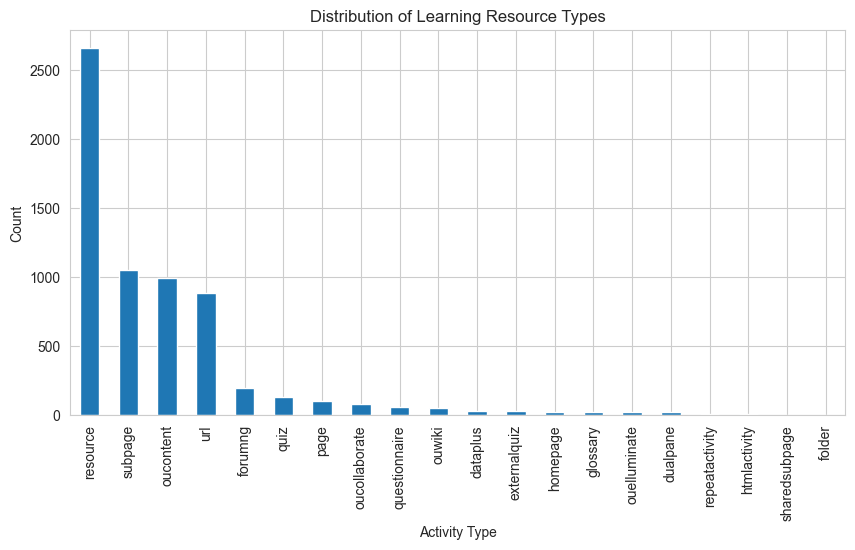

In [15]:
activity_counts = vle["activity_type"].value_counts()

plt.figure(figsize=(10,5))
activity_counts.plot(kind="bar")

plt.title("Distribution of Learning Resource Types")
plt.xlabel("Activity Type")
plt.ylabel("Count")

plt.show()

Student Performance Distribution

In [16]:
student_info["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

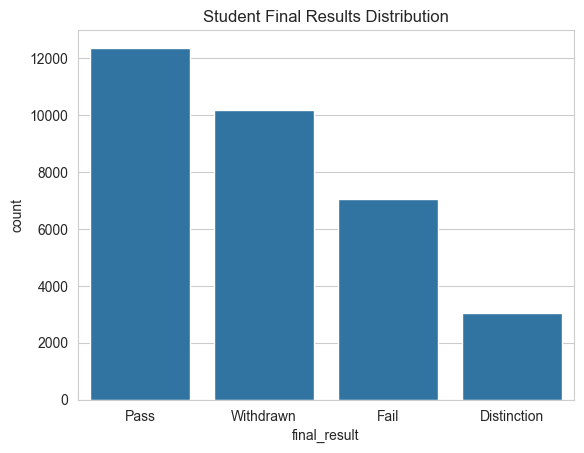

In [17]:
sns.countplot(data=student_info, x="final_result")
plt.title("Student Final Results Distribution")
plt.show()

Click Activity Distribution

In [18]:
student_vle["sum_click"].describe()

count    1.065528e+07
mean     3.716946e+00
std      8.849047e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      6.977000e+03
Name: sum_click, dtype: float64

Interaction Timeline

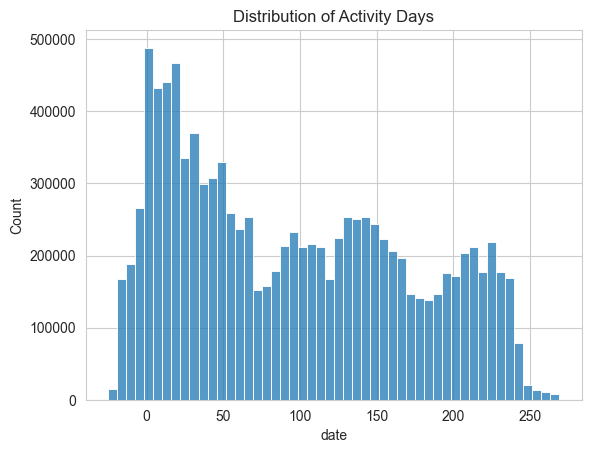

In [20]:
sns.histplot(student_vle["date"], bins=50)
plt.title("Distribution of Activity Days")
plt.show()

Merge Logs with Resource Types

In [21]:
logs = student_vle.merge(vle, on="id_site", how="left")
logs.head()

,code_module_x,code_presentation_x,id_student,id_site,date,sum_click,code_module_y,code_presentation_y,activity_type,week_from,week_to
0,AAA,2013J,28400,546652,-10,4,AAA,2013J,forumng,NaN,NaN
1,AAA,2013J,28400,546652,-10,1,AAA,2013J,forumng,NaN,NaN
2,AAA,2013J,28400,546652,-10,1,AAA,2013J,forumng,NaN,NaN
3,AAA,2013J,28400,546614,-10,11,AAA,2013J,homepage,NaN,NaN
4,AAA,2013J,28400,546714,-10,1,AAA,2013J,oucontent,NaN,NaN


Add Student Results

In [22]:
logs = logs.merge(student_info[["id_student","final_result"]], on="id_student")
logs.head()

,code_module_x,code_presentation_x,id_student,id_site,date,sum_click,code_module_y,code_presentation_y,activity_type,week_from,week_to,final_result
0,AAA,2013J,28400,546652,-10,4,AAA,2013J,forumng,NaN,NaN,Pass
1,AAA,2013J,28400,546652,-10,1,AAA,2013J,forumng,NaN,NaN,Pass
2,AAA,2013J,28400,546652,-10,1,AAA,2013J,forumng,NaN,NaN,Pass
3,AAA,2013J,28400,546614,-10,11,AAA,2013J,homepage,NaN,NaN,Pass
4,AAA,2013J,28400,546714,-10,1,AAA,2013J,oucontent,NaN,NaN,Pass


Activity vs Performance

In [23]:
activity_result = logs.groupby(["activity_type","final_result"]).size().reset_index(name="count")

activity_result.head()

,activity_type,final_result,count
0,dataplus,Distinction,4422
1,dataplus,Fail,574
2,dataplus,Pass,9401
3,dataplus,Withdrawn,740
4,dualpane,Distinction,2352


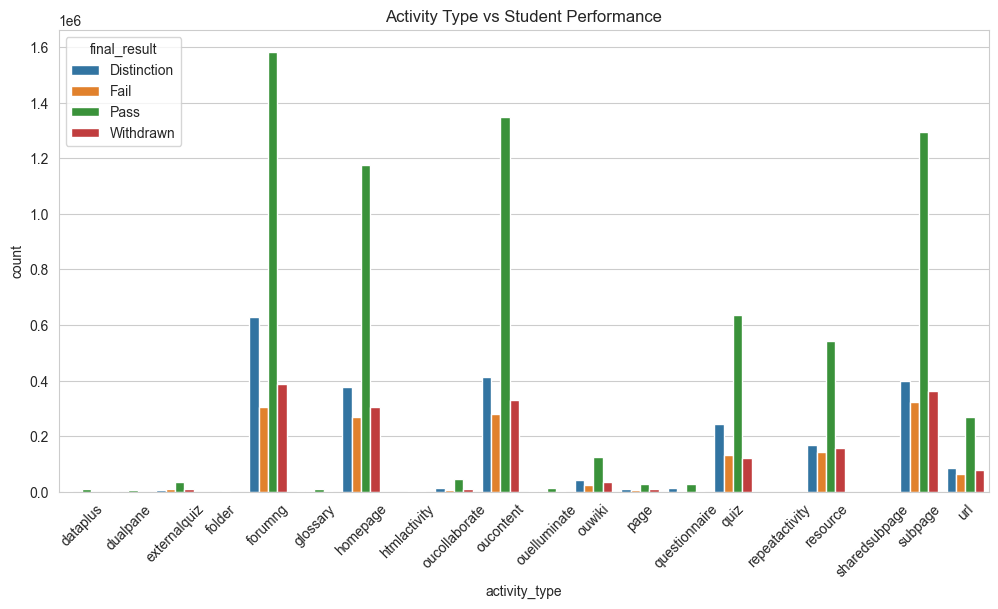

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(data=activity_result,
            x="activity_type",
            y="count",
            hue="final_result")

plt.xticks(rotation=45)

plt.title("Activity Type vs Student Performance")

plt.show()

Assessment Scores

In [25]:
student_assessment["score"].describe()

count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64

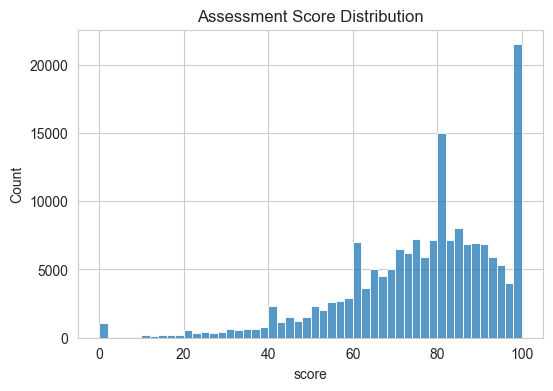

In [26]:
plt.figure(figsize=(6,4))

sns.histplot(student_assessment["score"], bins=50)

plt.title("Assessment Score Distribution")

plt.show()

## Key Observations

1. The dataset contains approximately 32,000 students.
2. studentVle records student interactions with LMS resources.
3. Resource types include forum, quiz, page, resource, and url.
4. Student performance is stored in studentInfo under final_result.
5. Assessment scores provide additional performance signals.
6. The date column allows construction of temporal behavior sequences.
7. Activity patterns differ across performance groups.